# Relating Brain to Stimuli


## 0. Prepare notebook (import, plot parameters)

Setting up the notebook, every import should be taken care of here. The second cell is mostly there for aesthetics purposes, so I encourage you to play around with it and find what you find the most visually pleasing! Careful with the dpi however as it will affect the size of all subsequent figures.

In [1]:
%load_ext autoreload
%autoreload 2

# Spyeeg import
import spyeeg.models as models
from spyeeg.generate import simulate_channels, simulate_multisensory_channels, simulate_continuous_stimuli, simulate_PAC

# Other useful imports
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import mne
import scipy.signal as signal
from sklearn.preprocessing import scale
import time
from scipy.signal import welch

In [2]:
mpl.rcParams.update(mpl.rcParamsDefault)

%matplotlib inline
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["b", "r", "g"]) 
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.linewidth'] = 0.4
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['font.size'] = 3.5
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['grid.alpha'] = 0.4
mpl.rcParams['grid.linewidth'] = 0.2
mpl.rcParams['lines.linewidth'] = 0.6


## 1. The idea behind Encoding
Vizualizing an LTI system: simple but useful model of brain response.

### 1.a Analogy with ERP
Here we simulate an electrophysiological signal which responds as a linear time-invariant system in response to discrete stimuli, it means that its response:
1) is consistent in time, similarly to the usual assumption behind ERP.
2) is a waveform which amplitude linearly depends on the amplitude of the stimuli.

To do so, we are using the simulate_channels function. It mostly serves to simulate random data so feel free to play around with the parameters.

Weights have incoherent shape relative to number of features, set to equal weights


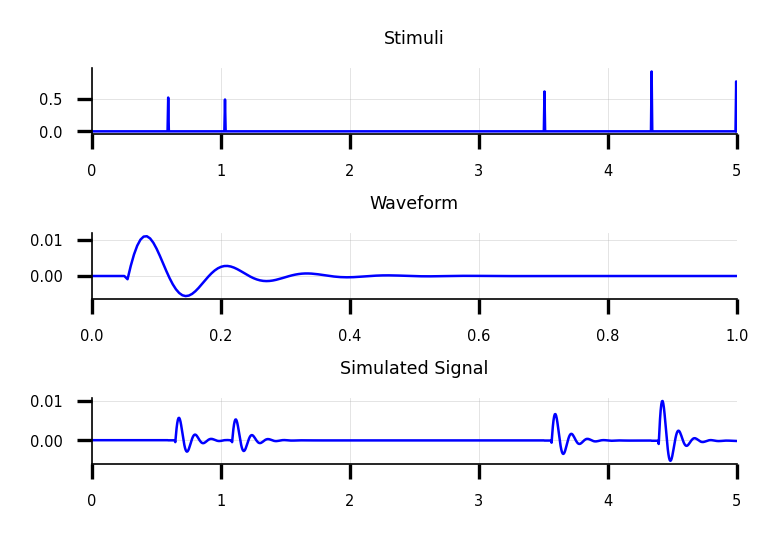

In [3]:
# Generate the Data without noise
fs = 200
n_feat = 1
n_channels = 1
T = 5
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,  
                                                              stim_type = 'discrete', n_pulse = T, 
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,5],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = np.inf, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 5, scale_data = False)


fig, ax = plt.subplots(3,figsize = (2.5,1.7))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

for i in range(3):
    ax[i].set_title(['Stimuli', 'Waveform', 'Simulated Signal'][i])
ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

Weights have incoherent shape relative to number of features, set to equal weights


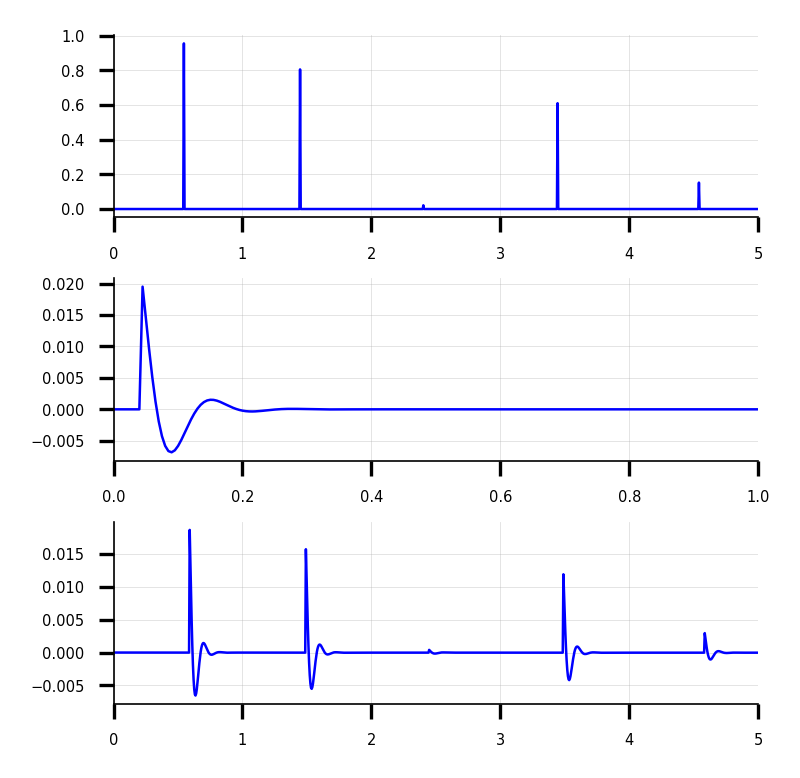

In [4]:
# Generate the Data without noise
fs = 200
n_feat = 1
n_channels = 1
T = 5
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,  
                                                              stim_type = 'discrete', n_pulse = T, 
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,5],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = np.inf, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 50, scale_data = False)

fig, ax = plt.subplots(3,figsize = (2.5,2.5))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

### 1.b Application to a continuous stimuli
While the response of an LTI is very straightforward and well-defined for discrete stimuli, it can actually be extended to continuous ones quite easily. An easy way to represent that idea is to imagine that at each point of time, the brain responds a discrete stimuli, which amplitude is the one of the continuous stimuli at that point in time.
We only need to change the "stim_type" parameter in the function to observe such a response.

Weights have incoherent shape relative to number of features, set to equal weights


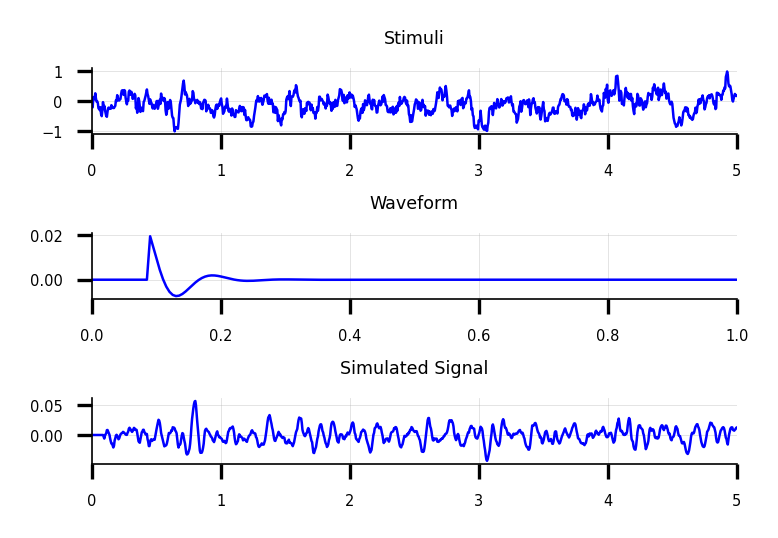

In [22]:
# Generate the Data without noise
fs = 200
n_feat = 1
n_channels = 1
T = 5
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,  
                                                              stim_type = 'continuous', n_pulse = T, 
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,5],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = np.inf, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 5, scale_data = False)


fig, ax = plt.subplots(3,figsize = (2.5,1.7))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

for i in range(3):
    ax[i].set_title(['Stimuli', 'Waveform', 'Simulated Signal'][i])
ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

### 1.c "Realistic" Data
Depending on the recording modality (intracortical shaft electrodes, ECoG, EEG, MEG...etc) and experimental design, the multidimensional signal will present different specificity: inter-channel correlation, spatio-temporal resolution, signal-to-noise ratio, duration. Here, for efficiency purposes, we will take the example of low-dimensional, high-snr, highly-correlated signal in response to a single stimuli for 10 minutes at 100Hz. This is typically the case of ECoG.
To achieve this, we will simply change the sampling frequency, n_feat, n_channels, share_impulse, weights_channel and snr_db parameters of our function. 
Please be aware that while we define a pinkish noise here, it would probably corresponds to "background" brain activity in a realistic case, what we define as noise or not 

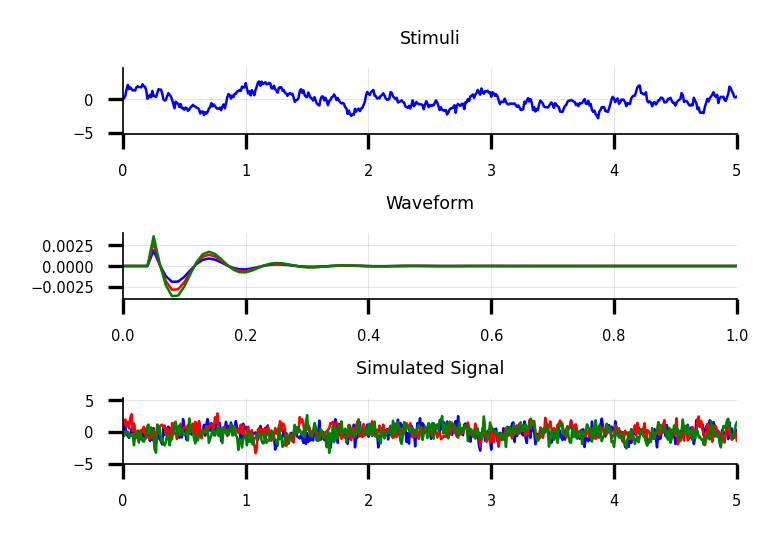

In [6]:
# Generate the Data with noise over 3 channels
fs = 100
n_feat = 1
n_channels = 3
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,  
                                                              stim_type = 'continuous', n_pulse = T, 
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -10, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = True)


fig, ax = plt.subplots(3,figsize = (2.5,1.7))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

for i in range(3):
    ax[i].set_title(['Stimuli', 'Waveform', 'Simulated Signal'][i])
ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

## 2. Technical Considerations
From stimulus to brain: how is information encoded in the brain. Here, our goal is to use the LTI as a framework to represent the response of individual channels to a (or multiple) stimuli.

In [151]:
# Generate Data for 3 channels in response to a single feature for 10 minutes.
fs = 100
n_feat = 1
n_channels = 3
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,  
                                                              stim_type = 'continuous', n_pulse = T, 
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -15, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

### 2.a Understanding the Temporal Response Function
Once the concept of LTI is understood, the TRF is actually quite obvious as it simply consists of directly learning the weights representing the response waveform (the "response function" if you will). Here we simply present how the TRF function operate in a typical case and the (very few) different steps to achieve results.

In [97]:
# First we define parameters relative to the TRF fitting: the temporal window (tmin, tmax), the regularization sweep (alphas)
# the fitting domain (fit_domain), the metrics to measure performance (metrics) and number of folds for the cross-validation (n_folds)
tmin = 0
tmax = 0.5
alphas = np.logspace(-3,3,10)
fit_domain = 'time'
metrics = 'R2'
n_folds = 5

# Then we declare the TRF: this allows to manipulate it as an object that stores all relevant information rather than just a function.
trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = fit_domain)

# Before fitting anything, it is ESSENTIAL to do proper preprocessing. As the saying goes in Machine Learning: "trash in, trash out", so have data as clean as possible
# In our case, this only involves properly scaling the data, the TRF does not fit the intercept and therefore everything needs to be centered in 0.
X = scale(X)
Y = scale(Y)

# Now, we can fit the data using cross-fold validation
trf.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False)

# The trf object is now fitted and we can extract the scores, the TRF coefficients...etc
trf_times = trf.times
scores = trf.scores
coefficients = trf.get_coef()

We've now obtained scores (according to the chosen metrics, here R2) and coefficients, let's take a look at their shape!

In [54]:
print("Scores have a shape of (n_folds,n_channels,n_alphas): ", scores.shape)
print("Coefficients have a shape of (window_width, n_features, n_channels, n_alphas): ", coefficients.shape)

Scores have a shape of (n_folds,n_channels,n_alphas):  (5, 3, 10)
Coefficients have a shape of (window_width, n_features, n_channels, n_alphas):  (50, 1, 3, 10)


The folds are always averaged and generally the best alpha is chosen. When multiple subjects are presented, it is good practise to choose the average alpha parameter, or better even, do nested cross-validation. This however can be time consuming, so it depends on your needs and data. Here, we'll select the best alpha.

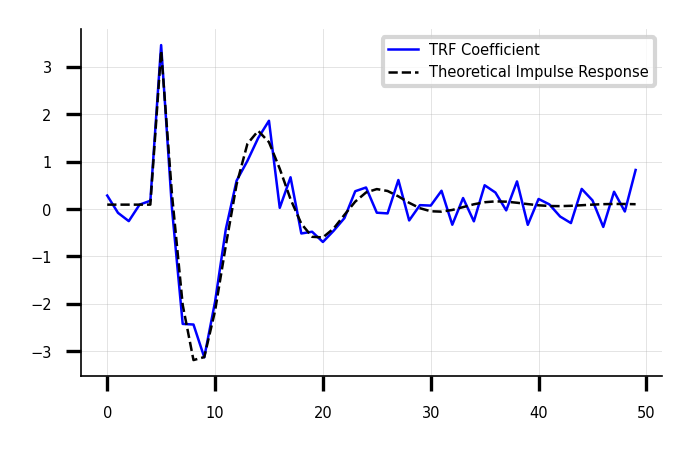

In [55]:
fig, ax = plt.subplots(figsize = (2.5,1.5))
ax.plot(scale(coefficients[:50,0,0,2]), label = 'TRF Coefficient')
ax.plot(scale(impulse_responses[0,0,0:50]), ls = '--',color = 'k', label = 'Theoretical Impulse Response', alpha = 1)
ax.legend(fancybox = True)

### 2.b Testing the metrics
Once the signal is reconstructed, different metrics can be used to quantify the quality of the fit. They are generally related and have different uses depending on the scenario. We will also briefly talk of their signification and how the nomenclature can be misleading (R squared is not the square of R...at least, not always!). 

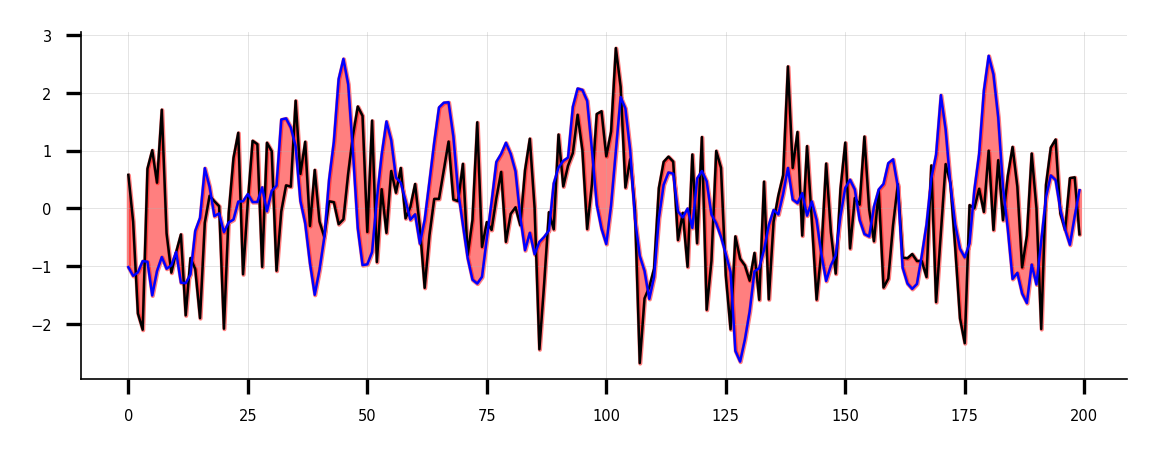

In [56]:
fig, ax = plt.subplots(figsize = (4.5,1.5))
ax.plot(scale(Y[300:500,0]), color = 'k')
ax.plot(scale(trf.predict(X)[300:500,0,2]))
ax.fill_between(np.arange(200),scale(trf.predict(X)[300:500,0,2]), scale(Y[300:500,0]), alpha = 0.5, color = 'r')


#### Different metrics to quantify different aspects

In [57]:
tmin = 0
tmax = 1
metrics = ['R2', 'corr', 'rankcorr']
scores = np.zeros([len(metrics), n_channels])
for i_metric, metric in enumerate(metrics):
    trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
    trf_times = trf.times
    trf.xval_eval(X, Y, scoring = metric, verbose = False)
    scores[i_metric] = trf.scores.mean(0).max(-1)

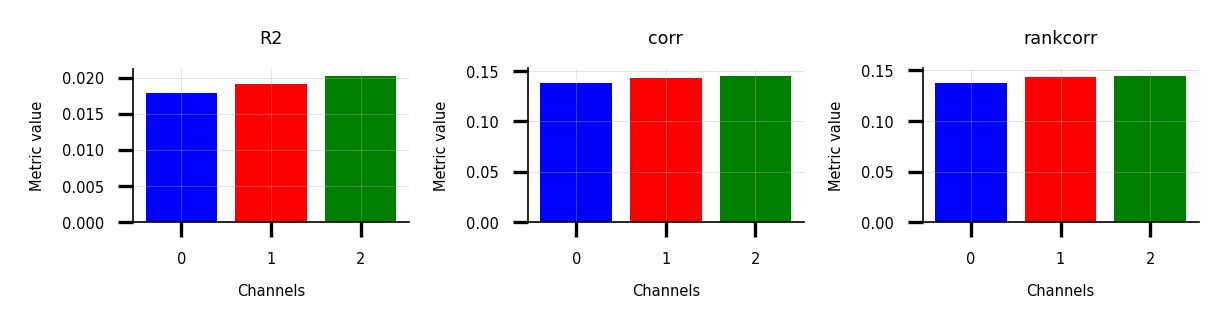

In [65]:
fig, ax = plt.subplots(1,len(metrics), figsize = (4,1))
for i_metric in range(len(metrics)):
    ax[i_metric].bar(np.arange(3),scores[i_metric], color = ['b','r','g'])
    ax[i_metric].set_title(metrics[i_metric])
    ax[i_metric].set_xticks(np.arange(n_channels))
    ax[i_metric].set_xlabel('Channels')
    ax[i_metric].set_ylabel('Metric value')
fig.tight_layout()

#### R2 is negatively biased

In [69]:
tmin = 0
tmax_list = [0.5,1,2]
metric = 'R2'
scores = np.zeros([len(tmax_list), n_channels])
for i_tmax, tmax in enumerate(tmax_list):
    trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
    trf_times = trf.times
    trf.xval_eval(X, Y, scoring = metric, verbose = False)
    scores[i_tmax] = trf.scores.mean(0).max(-1)

TypeError: object of type 'float' has no len()

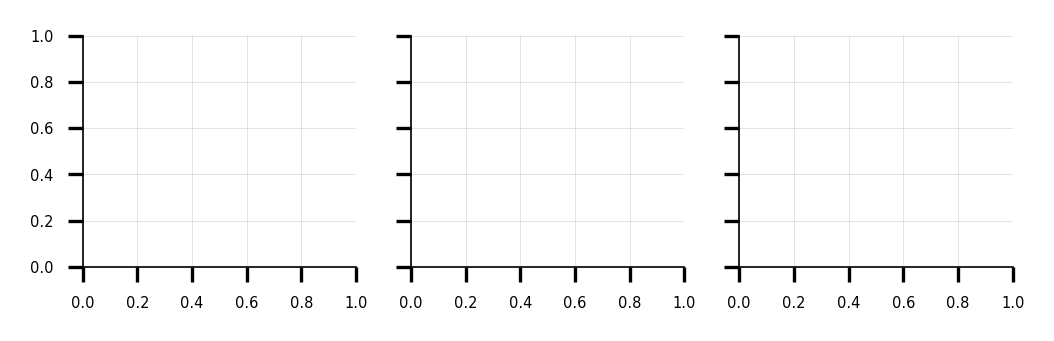

In [88]:
fig, ax = plt.subplots(1,len(metrics), figsize = (4,1), sharey = True)
for i_tmax in range(len(tmax_list)):
    ax[i_tmax].bar(np.arange(3),scores[i_tmax], color = ['b','r','g'])
    ax[i_tmax].set_title(metrics[i_tmax])
    ax[i_tmax].set_xticks(np.arange(n_channels))
    ax[i_tmax].set_xlabel('Channels')
    ax[i_tmax].set_ylabel('Metric value')
fig.tight_layout()

#### Comparison of differently sized models

In [94]:
tmin = 0
tmax = 0.5
metric = 'R2'
n_noisy_features = 3
scores = np.zeros([n_noisy_features, n_channels])
for i_noise in range(n_noisy_features):
    X1 = np.random.random((X.shape[0], i_noise))
    X_tot = scale(np.hstack([X,X1]))
    trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
    trf_times = trf.times
    trf.xval_eval(X_tot, Y, scoring = metric, verbose = False)
    scores[i_noise] = trf.scores.mean(0).max(-1)

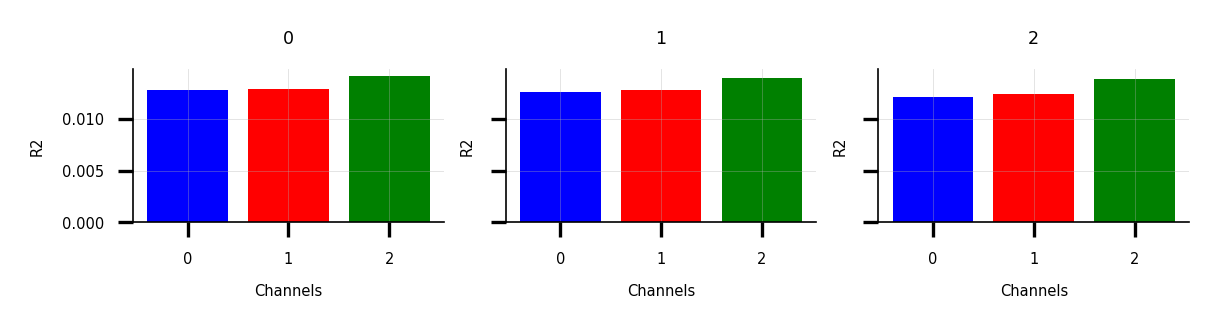

In [96]:
fig, ax = plt.subplots(1,n_noisy_features, figsize = (4,1), sharey = True)
for i_noise in range(n_noisy_features):
    ax[i_noise].bar(np.arange(3),scores[i_noise], color = ['b','r','g'])
    ax[i_noise].set_title(str(i_noise))
    ax[i_noise].set_xticks(np.arange(n_channels))
    ax[i_noise].set_xlabel('Channels')
    ax[i_noise].set_ylabel('R2')
fig.tight_layout()

### 2.c Cross-Validation

With actual data and with just noise

In [120]:
tmin = 0
tmax = 0.5
scores = np.zeros([2, n_channels])

trf_xval = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
trf_times = trf_xval.times
trf_xval.xval_eval(X, Y, scoring = metric, verbose = False)
scores[0] = trf_xval.scores.mean(0).max(-1)

trf_leak = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
coefs = trf_leak.fit(X,Y)
scores[1] = trf_leak.score(X,Y).max(1)

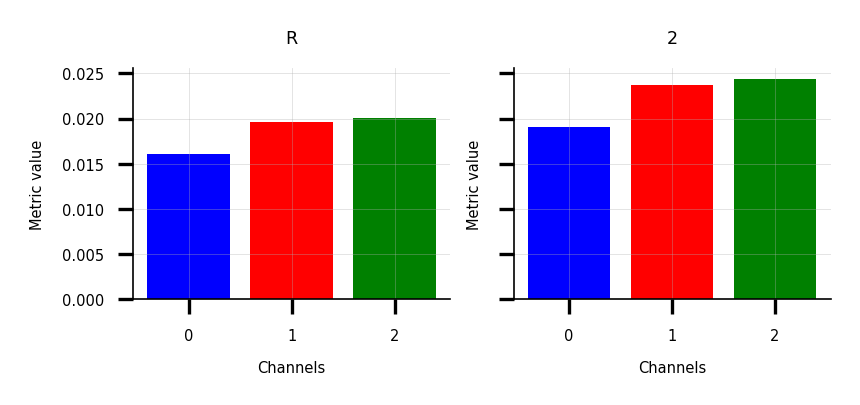

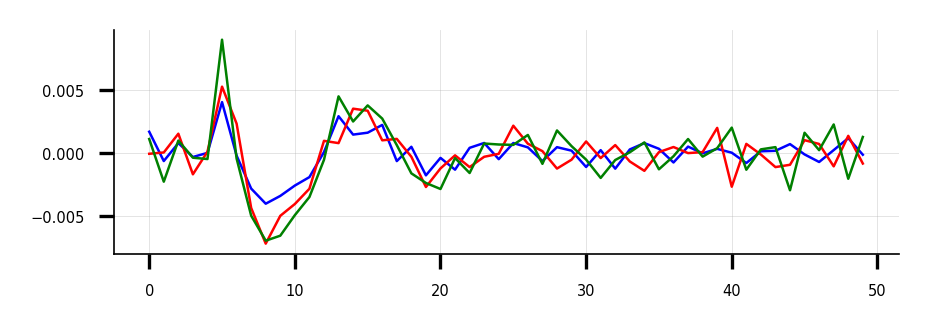

In [124]:
fig, ax = plt.subplots(1,2, figsize = (3,1), sharey = True)
for i in range(2):
    ax[i].bar(np.arange(3),scores[i], color = ['b','r','g'])
    ax[i].set_title(metrics[i])
    ax[i].set_xticks(np.arange(n_channels))
    ax[i].set_xlabel('Channels')
    ax[i].set_ylabel('Metric value')
fig, ax = plt.subplots(figsize = (3,1))
ax.plot(coefs[::-1,:,0])
fig.tight_layout()

In [126]:
tmin = 0
tmax = 0.5
scores = np.zeros([2, n_channels])
X_noise = np.random.random(X.shape)

trf_xval = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
trf_times = trf_xval.times
trf_xval.xval_eval(X_noise, Y, scoring = metric, verbose = False)
scores[0] = trf_xval.scores.mean(0).max(-1)

trf_leak = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
coefs = trf_leak.fit(X_noise,Y)
scores[1] = trf_leak.score(X_noise,Y).max(1)

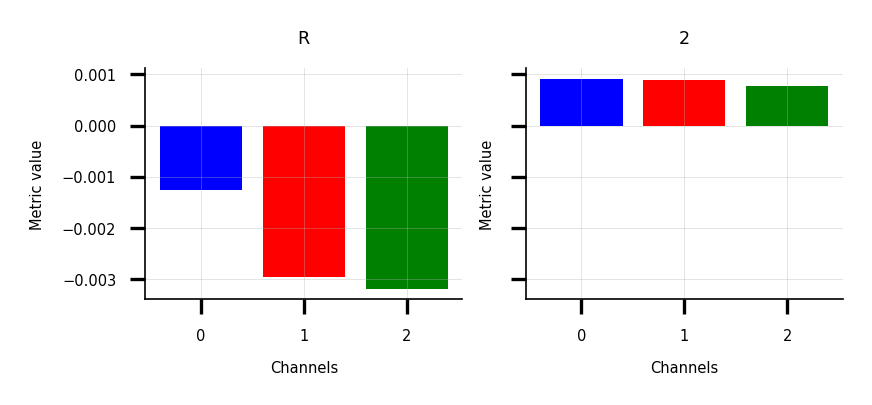

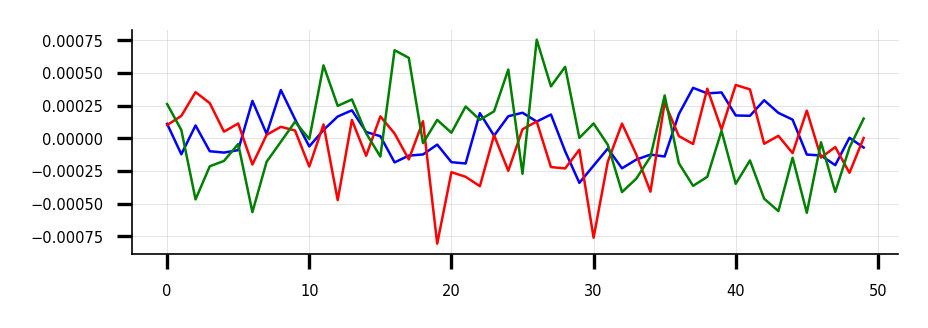

In [127]:
fig, ax = plt.subplots(1,2, figsize = (3,1), sharey = True)
for i in range(2):
    ax[i].bar(np.arange(3),scores[i], color = ['b','r','g'])
    ax[i].set_title(metrics[i])
    ax[i].set_xticks(np.arange(n_channels))
    ax[i].set_xlabel('Channels')
    ax[i].set_ylabel('Metric value')
fig, ax = plt.subplots(figsize = (3,1))
ax.plot(coefs[::-1,:,0])
fig.tight_layout()

### 2.d Regularization

In [173]:
# Generate Data for 3 channels in response to a single feature for 10 minutes.
fs = 100
n_feat = 1
n_channels = 1
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,  
                                                              stim_type = 'continuous', n_pulse = T, 
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -20, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

In [191]:
tmin = 0
tmax = 1
alphas = [0] + list(np.logspace(-5,5,20))

trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
trf_times = trf.times
trf.xval_eval(X, Y, scoring = metric, verbose = False)
scores = trf.scores.mean(0)[0]
coefficients = trf.get_coef()[:,0,0,:]


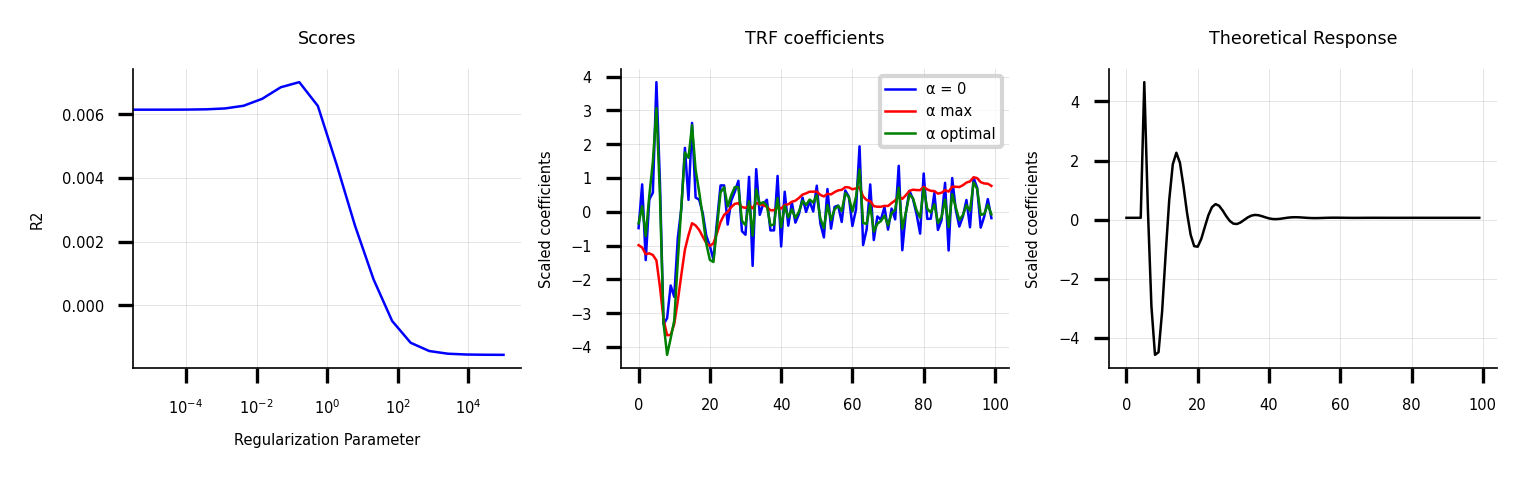

In [207]:
fig,ax = plt.subplots(1,3,figsize = (5,1.5))
ax[0].plot(alphas, scores)
ax[0].set_ylabel('R2')
ax[0].set_xlabel('Regularization Parameter')
ax[0].set_xscale('log')
ax[0].set_title('Scores')

for i in range(3):
    ax[1].plot(scale(coefficients[:,[0,-1,np.argmax(scores)][i]]), label = ['α = 0', 'α max', 'α optimal'][i])
ax[1].legend()
ax[1].set_title('TRF coefficients')
ax[1].set_ylabel('Scaled coefficients')

ax[2].plot(scale(impulse_responses[0,0,:100]), color = 'k')
ax[2].set_title('Theoretical Response')
ax[2].set_ylabel('Scaled coefficients')

fig.tight_layout()

### 2.e Understanding the Coefficients
As said earlier, coefficients can be interpreted, here we will go over how to interpret them but also assess their significance and how they can be more interesting to look at than the scores in specific cases.

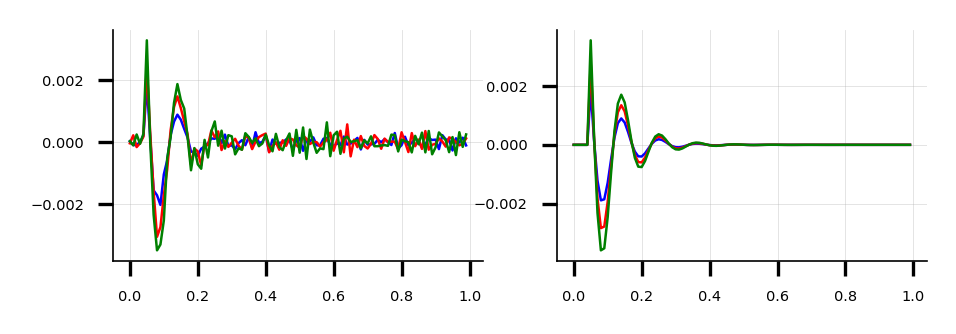

In [218]:
fig, ax = plt.subplots(1,2,figsize = (3.5,1))
for i in range(3):
    ax[0].plot(trf.times,trf.get_coef()[:,0,i,0])
    ax[1].plot(time_array[:100],impulse_responses[0,i,:100])

### 2.f Model Comparison and Statistical Evaluation
Often, fitting a single model does not tell us a lot about what's going on. Here we will talk about how to compare models, what models to compare, with an emphasis on the concept of null distribution and the importance of same-size models.

In [236]:
n_perm = 50
X_perm = np.zeros([X.shape[0],1])
scores_perm = np.zeros([n_channels,n_perm])
start = time.time()
for i in range(n_perm):
    X_perm[:,0] = np.roll(X[:,0],np.random.randint(100,X.shape[0] - 100))
    trf_perm = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
    scores_perm[:,i] = trf_perm.xval_eval(X_perm, Y, scoring = 'R2', verbose = False).mean(0).max(-1)
print(time.time() - start)

(array([ 2.,  2.,  5.,  5., 10., 11.,  6.,  4.,  2.,  3.]),
 array([-0.0046202 , -0.00449096, -0.00436172, -0.00423248, -0.00410324,
        -0.003974  , -0.00384476, -0.00371552, -0.00358628, -0.00345705,
        -0.00332781]),
 <BarContainer object of 10 artists>)

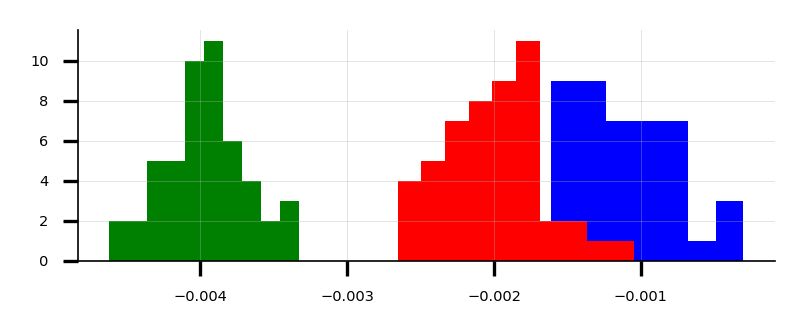

In [571]:
fig, ax = plt.subplots(figsize = (3,1))
ax.hist(scores_perm[0], bins = 10)
ax.hist(scores_perm[1], bins = 10)
ax.hist(scores_perm[2], bins = 10)

### 2.h Computing Time: Understanding the technical constraints (bonus)

## 3. Applications of Encoding

### 3.a "X" is processed in the brain 
Generally, forward models aim to answer the question of "is this feature relevant in predicting brain activity", hence why it is also called "encoding". One great advantage of the TRF is that it is fully linear making its coefficients easily interpretable, at least for a low number of orthogonal features.

### 3.b Multisensory Interaction

In [ ]:
fs = 100
n_feat = 1
n_channels = 1
T = 120

time_array, X, Y1,Y2,Y12, events, impulse_responses = simulate_multisensory_channels(n_feat = n_feat, n_channels = n_channels, 
                                                              fs = fs, T = T,  
                                                              stim_type = 'discrete', n_pulse = T * 8, 
                                                              impulse_freqs = [2,20], decreasing_rates = [20,25], delays = [0.03,0.2],
                                                              compression_factor = 1, 
                                                              snr_db = 10, beta_noise = 1, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 10, scale_data = False, supra_amp = 0)
fig, ax = plt.subplots(5,figsize = (3,2.5), sharex = False)
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        for k in range(2):
            ax[1].plot(time_array,impulse_responses[k,i,j] + k, alpha = 1)
        ax[1].plot(time_array,impulse_responses[2,i,j] - impulse_responses[0,i,j] - impulse_responses[1,i,j] + 2, alpha = 1)
ax[2].plot(time_array,Y1)
ax[3].plot(time_array,Y2)
ax[4].plot(time_array,Y12)
ax[0].set_xlim([0,100])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,10])
ax[3].set_xlim([0,10])
ax[4].set_xlim([0,10])


### 3.c Handling simple non-linearities

### 3.d Controlling for lower level features
Most of the time, we dispose of "control features", which are features we already know encode brain activity. Wanting to test an additional hypothesis then becomes a question of "does this feature encode additional information?".

### 3.e Targetting specific neural functions
Up until now, we've assumed the TRF made a direct link between the data and stimuli, however, as explained in previous sessions, the activity picked up by electrodes is a sum of several sources, some of which may interact. Here we will focus on one example of specific brain function (or interaction between sources) and how/why it could be encoded by the TRF.

In [542]:
# Generate Data
fs = 100
n_feat = 1
n_channels = 1
alphas = np.logspace(-2,2,5)
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,  
                                                              stim_type = 'discrete', n_pulse = 3*T, 
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = np.inf, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = True,
                                                               target_signal = 'PAC', PAC_lf = 1, PAC_hf= 15)

X = scale(X, with_std = True)

Weights have incoherent shape relative to number of features, set to equal weights


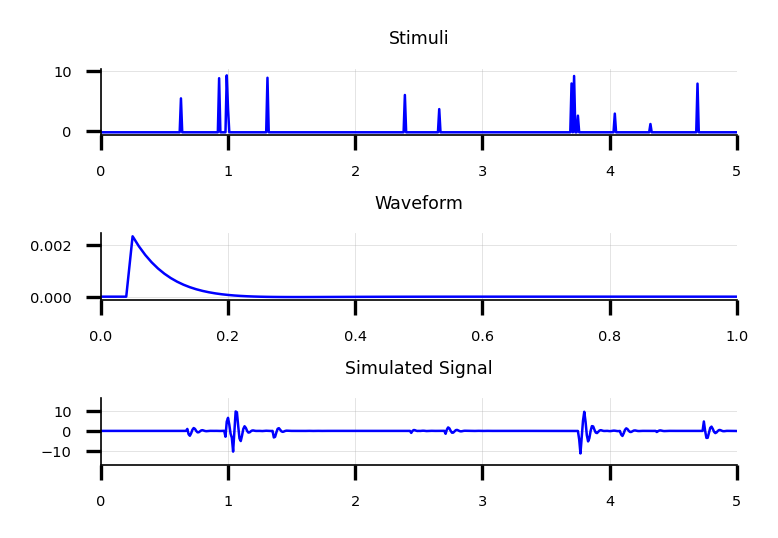

In [543]:
fig, ax = plt.subplots(3,figsize = (2.5,1.7))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

for i in range(3):
    ax[i].set_title(['Stimuli', 'Waveform', 'Simulated Signal'][i])
ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

In [544]:
tmin = 0
tmax = 1
trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
trf_times = trf.times
trf.xval_eval(X, Y, verbose = False)
scores = trf.scores

In [545]:
print(scores.mean(0).max(-1))

[0.00034274]


In [552]:
s1 = mne.filter.filter_data(Y[:,0],fs,0.5,2, verbose = False)
s2 = mne.filter.filter_data(Y[:,0],fs,10,20, verbose = False)

phase = np.angle(signal.hilbert(s1))
amplitude = np.cos(phase)
pac = amplitude * s2


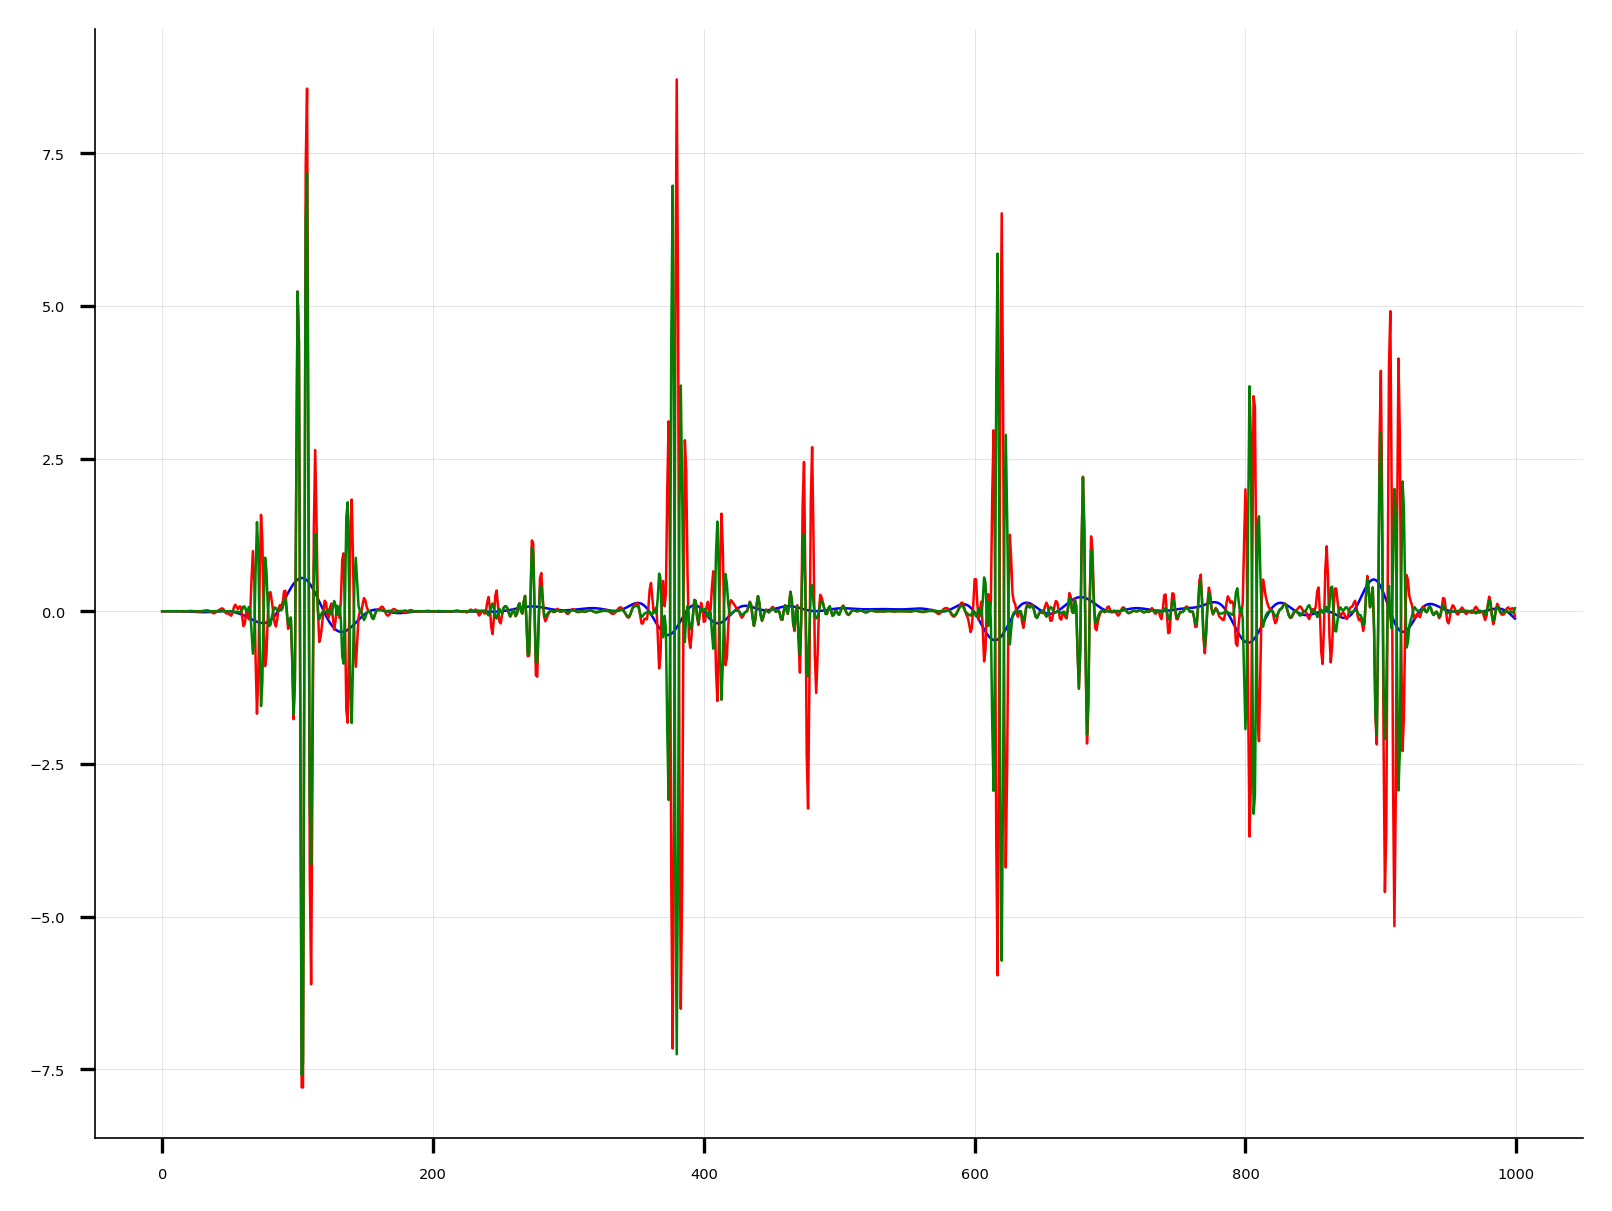

In [553]:
plt.plot(s1[:1000])
plt.plot(s2[:1000])
plt.plot(pac[:1000])

In [554]:
tmin = 0
tmax = 1
trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
trf_times = trf.times
trf.xval_eval(scale(X), scale(pac[:,np.newaxis]), verbose = False)
scores = trf.scores

In [555]:
scores.mean(0).max(-1)

array([0.29028872])

In [782]:
a = simulate_PAC(0.8,time_array,3,20)

In [786]:
plt.plot(a[:300])

### 3.f Dimensionality Reduction, when and why? (bonus)

### 3.g Handling non-linearity using Reservoir Computing (bonus)

## 4. Backward Modelling and bidirectional models
Unlike the Forward Modelling, Backward Modelling works in "the reverse order", in that, we decode the stimuli from the response it supposedly evoked. This matters in terms of interpretation of the coefficients but also flips how we think of features and brain signals, especially in terms of noise. Backward model generally answers a different question from forward one: "Does the brain signal contain information about the feature".

### 4.a Flipping the time : Concept of backwards model

In [568]:
fs = 100
n_feat = 1
n_channels = 3
T = 600

time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,  
                                                              stim_type = 'continuous', n_pulse = T, 
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -10, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

X = scale(X, with_std = False)

tmin = -0.5
tmax = 0.5
trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
trf_times = trf.times
trf.xval_eval(Y, X, verbose = False)
scores = trf.scores.mean(0).max(-1)
print(scores)

### 4.b Exploiting Redundancy in neural data

### 4.c Back to Back Regression (bonus)